In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/WIN 11/Desktop/bengaluru_house_prices.csv")


print("Shape:", df.shape)
df.head()

Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None


In [3]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [4]:
df = df.drop('society', axis=1)

In [5]:
df = df.dropna(subset=['location', 'size'])

df['bath'] = df['bath'].fillna(df['bath'].median())

df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [6]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [7]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

df[['size', 'bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [8]:
df = df.drop('size', axis=1)

In [9]:
def convert_sqft(x):
    try:
        if '-' in x:
            values = x.split('-')
            return (float(values[0]) + float(values[1])) / 2
        return float(x)
    except:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)



In [10]:
df = df.dropna(subset=['total_sqft'])

In [11]:
df['total_sqft'].describe()

count    13257.000000
mean      1558.809175
std       1238.478935
min          1.000000
25%       1100.000000
50%       1275.000000
75%       1680.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [12]:
df = df[df['bhk'] <= 10]

In [13]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [14]:
df['price_per_sqft'].describe()

count    1.324500e+04
mean     7.909280e+03
std      1.065455e+05
min      2.678298e+02
25%      4.270109e+03
50%      5.434783e+03
75%      7.310871e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [15]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['price_per_sqft'] >= lower) &
    (df['price_per_sqft'] <= upper)
]

In [16]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

In [17]:
df = df[df['sqft_per_bhk'] >= 300]

In [18]:
df = df.drop('sqft_per_bhk', axis=1)

In [19]:
df = df.drop('price_per_sqft', axis=1)

In [20]:
print("Final shape:", df.shape)

print(df.head())

print(df.isnull().sum())

Final shape: (11658, 8)
              area_type   availability                  location  total_sqft  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      1056.0   
1            Plot  Area  Ready To Move          Chikka Tirupathi      2600.0   
2        Built-up  Area  Ready To Move               Uttarahalli      1440.0   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      1521.0   
4  Super built-up  Area  Ready To Move                  Kothanur      1200.0   

   bath  balcony   price  bhk  
0   2.0      1.0   39.07    2  
1   5.0      3.0  120.00    4  
2   2.0      3.0   62.00    3  
3   3.0      1.0   95.00    3  
4   2.0      1.0   51.00    2  
area_type       0
availability    0
location        0
total_sqft      0
bath            0
balcony         0
price           0
bhk             0
dtype: int64


In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder_area = OneHotEncoder(
    drop='first',
    sparse_output=False,
    dtype=int
)

encoded_area = encoder_area.fit_transform(df[['area_type']])

In [22]:
encoded_area_df = pd.DataFrame(
    encoded_area,
    columns=encoder_area.get_feature_names_out(['area_type']),
    index=df.index
)

In [23]:
df = pd.concat(
    [
        df.drop('area_type', axis=1),
        encoded_area_df
    ],
    axis=1
)

In [24]:
encoder_location = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore',
    dtype=int
)

encoded_location = encoder_location.fit_transform(df[['location']])

In [25]:
encoded_location_df = pd.DataFrame(
    encoded_location,
    columns=encoder_location.get_feature_names_out(['location']),
    index=df.index
)

In [26]:
df = pd.concat(
    [
        df.drop('location', axis=1),
        encoded_location_df
    ],
    axis=1
)

In [27]:
from sklearn.preprocessing import OneHotEncoder

encoder_availability = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore',
    dtype=int
)

encoded_availability = encoder_availability.fit_transform(
    df[['availability']]
)

encoded_availability_df = pd.DataFrame(
    encoded_availability,
    columns=encoder_availability.get_feature_names_out(['availability']),
    index=df.index
)

df = pd.concat(
    [
        df.drop('availability', axis=1),
        encoded_availability_df
    ],
    axis=1
)

In [28]:
X = df.drop('price', axis=1)
y = df['price']

In [29]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11658, 1209)
y shape: (11658,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression
MAE: 23.38531252678591
RMSE: 42.93532001102052
R²: 0.6124534818316851


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


In [34]:

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 16.796151014663224
RMSE: 35.628218142622465
R²: 0.7331405193427785


In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [36]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting
MAE: 19.442356087530033
RMSE: 36.126490002574975
R²: 0.7256240966625566


In [37]:
results = {
    'Random Forest': [rf_mae, rf_rmse, rf_r2],
    'Gradient Boosting': [gb_mae, gb_rmse, gb_r2]
}

results_df = pd.DataFrame(
    results,
    index=['MAE', 'RMSE', 'R²']
).T

print(results_df)

                         MAE       RMSE        R²
Random Forest      16.796151  35.628218  0.733141
Gradient Boosting  19.442356  36.126490  0.725624


In [ ]:

from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}



In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 16.796151014663224
RMSE: 35.628218142622465
R²: 0.7331405193427785


In [45]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                             Feature  Importance
0                         total_sqft    0.729460
337        location_Dodsworth Layout    0.072990
3                                bhk    0.024321
1                               bath    0.016468
2                            balcony    0.009207
904       location_Sathya Sai Layout    0.008419
1160             availability_18-Jul    0.006045
1089             location_Whitefield    0.005404
5               area_type_Plot  Area    0.005125
6     area_type_Super built-up  Area    0.003516
1208      availability_Ready To Move    0.002957
499                  location_Jakkur    0.002676
440                  location_Hebbal    0.002367
897          location_Sarjapur  Road    0.002005
841            location_Rajaji Nagar    0.001971


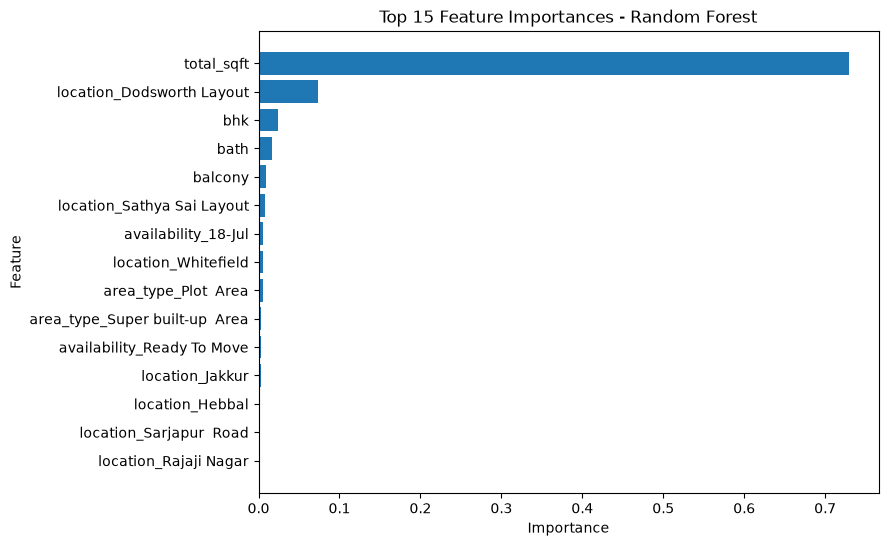

In [46]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest')

plt.gca().invert_yaxis()

plt.show()

In [47]:
import joblib

joblib.dump(rf_model, 'bengaluru_house_price_model.pkl')

print("Model saved successfully!")

Model saved successfully!
